In [ ]:
!pip install qiskit==1.1
!pip install numpy
!pip install matplotlib
!pip install pylatexenc
!pip install qiskit_algorithms==0.3.1
!pip install qiskit_nature
!pip install pyscf
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.3/50.3 MB 17.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=e5a42fddf590bc8ad64ad40fb10fa0f4b8b3b4adf75dda118526caa0e309af78
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.5/310.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import numpy as np
from qiskit import *
from qiskit_algorithms.optimizers import SPSA, SLSQP, COBYLA,CG, POWELL
from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver
from qiskit_algorithms.eigensolvers import NumPyEigensolver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.mappers import BravyiKitaevMapper
from qiskit.primitives import Estimator
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import TwoLocal
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock, UCC
from qiskit.primitives import Estimator
ideal_estimator = Estimator()
from qiskit_algorithms.optimizers import L_BFGS_B,SPSA
from qiskit_algorithms import VQE
import matplotlib.pyplot as plt

2
The VQE energy using Twolocal is -0.4665818265656648
Exact energy is -0.46658184955727533
Number of qubits is 2


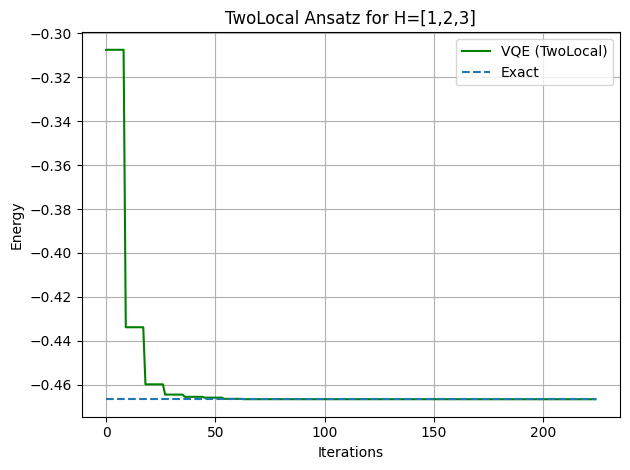

In [ ]:
driver = PySCFDriver(atom=f"H 0 0 0", charge=0, spin=1, basis="sto3g")
problem = driver.run()
hamiltonian = problem.hamiltonian
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
#Original Composition
num_particles = problem.num_particles  # This gives a tuple: (alpha_electrons, beta_electrons)
total_electrons = sum(num_particles)
num_spin_orbitals = problem.num_spin_orbitals
num_spatial_orbitals = num_spin_orbitals // 2


second_q_h = hamiltonian.second_q_op()
mapper2 = JordanWignerMapper()
hamiltonian_op = mapper2.map(second_q_h)



number_qubit2 = hamiltonian_op.num_qubits
print(number_qubit2)

ansatz1 = TwoLocal(num_qubits=2,rotation_blocks=['ry', 'rz'], entanglement_blocks=['cx'], entanglement='linear', reps=1)


#VQE FOR Twolocal

def store_in_between_result1(eval_count, parameters, mean, std):
        counts1.append(eval_count)
        values1.append(mean)
        params1.append(parameters)
counts1 = []
values1 = []
params1 = []


vqe_solver1 = VQE(ideal_estimator, ansatz1, optimizer=L_BFGS_B(maxiter=100), callback=store_in_between_result1)
simulation1 = vqe_solver1.compute_minimum_eigenvalue(hamiltonian_op)
energy1 = simulation1.eigenvalue





print(f'The VQE energy using Twolocal is {energy1}')

#Exact energy
exact2 = NumPyEigensolver().compute_eigenvalues(hamiltonian_op)
exact2 = np.real(exact2.eigenvalues[0])
print(f'Exact energy is {exact2}')
print(f'Number of qubits is {number_qubit2}')


#Plotting



plt.plot(values1 , label='VQE (TwoLocal)', color='green')
plt.plot((exact2 ) * np.ones(len(counts1)), "--", label='Exact')
plt.xlabel('Iterations')
plt.ylabel('Energy')
plt.title('TwoLocal Ansatz for H=[1,2,3]')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
repulsion = hamiltonian.constants.get('nuclear_repulsion_energy')
repulsion

0

Enter the no. of qubits for hamoltonian  2
Target qubits  2
SparsePauliOp(['ZZ'],
              coeffs=[1.+0.j])
The VQE energy using Twolocal is -0.999999999971459
Exact energy is -1.0
Number of qubits is 2


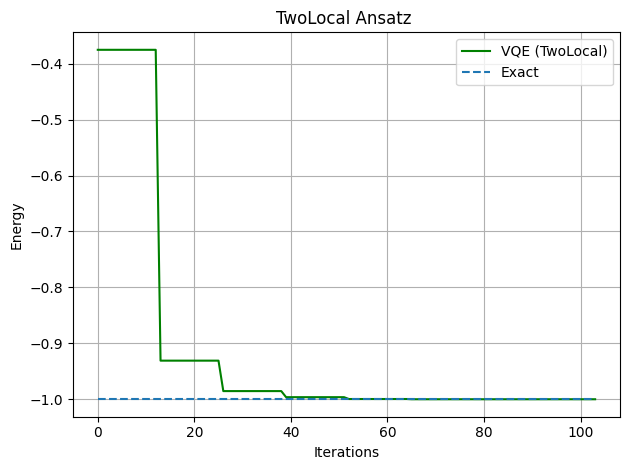

In [18]:
from math import cos,sin,pi
target_qubits = int(input("Enter the no. of qubits for hamoltonian  "))
print("Target qubits ",target_qubits)
def ising_hamitonian(num,m):
  lit1 = ['I'*num]*(num-1)
  for i in range(len(lit1)):
    s = list(lit1[i])
    s[i]='Z'
    s[i+1]='Z'
    lit1[i] =''.join(s)

  # lit2 = ['I'*num]*(num)
  # for j in range(len(lit2)):
  #   s1 = list(lit2[j])
  #   s1[j] = 'Z'
  #   lit2[j] = ''.join(s1)

  # lit3 = ['I'*num]*(num)
  # for k in range(len(lit3)):
  #   s2 = list(lit3[k])
  #   s2[k] = 'X'
  #   lit3[k] = ''.join(s2)

  hamilt = SparsePauliOp(lit1, coeffs=[m])

  # if abs(sin(alpha)) > 1e-12:
  #       hamilt += SparsePauliOp(lit2, coeffs=[-h*sin(alpha)]*num)
  # if abs(cos(alpha)) > 1e-12:
  #       hamilt += SparsePauliOp(lit3, coeffs=[-h*cos(alpha)]*num)

  return hamilt
  # hamilt = hamilt3 + hamilt2 + hamilt1
  # return hamilt
hamiltonian_ising = ising_hamitonian(target_qubits,1)
print(hamiltonian_ising)

ansatz = TwoLocal(num_qubits=target_qubits, rotation_blocks=['ry', 'rz'], entanglement_blocks=['cx'], entanglement='full', reps=2)

def store_in_between_result1(eval_count, parameters, mean, std):
        counts1.append(eval_count)
        values1.append(mean)
        params1.append(parameters)
counts1 = []
values1 = []
params1 = []


vqe_solver1 = VQE(ideal_estimator, ansatz, optimizer=L_BFGS_B(maxiter=100), callback=store_in_between_result1)
simulation1 = vqe_solver1.compute_minimum_eigenvalue(hamiltonian_ising)
energy1 = simulation1.eigenvalue





print(f'The VQE energy using Twolocal is {energy1}')

#Exact energy
exact2 = NumPyEigensolver().compute_eigenvalues(hamiltonian_ising)
exact2 = np.real(exact2.eigenvalues[0])
print(f'Exact energy is {exact2}')
print(f'Number of qubits is {number_qubit2}')


#Plotting



plt.plot(values1 , label='VQE (TwoLocal)', color='green')
plt.plot((exact2 ) * np.ones(len(counts1)), "--", label='Exact')
plt.xlabel('Iterations')
plt.ylabel('Energy')
plt.title('TwoLocal Ansatz ')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()